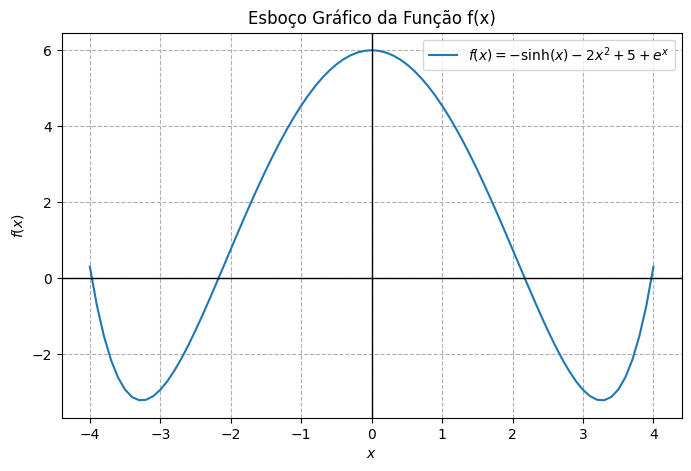

Iter  | x_k          | ea           | |f(x)|      
--------------------------------------------------
1     | 2.09310722   | 4.4483e-02   | 3.5449e-01  
2     | 2.13502806   | 1.9635e-02   | 1.7107e-01  
3     | 2.15496665   | 9.2524e-03   | 8.3992e-02  
4     | 2.16468875   | 4.4912e-03   | 4.1583e-02  
5     | 2.16948586   | 2.2112e-03   | 2.0671e-02  
6     | 2.17186662   | 1.0962e-03   | 1.0297e-02  
7     | 2.17305157   | 5.4529e-04   | 5.1343e-03  
8     | 2.17364217   | 2.7171e-04   | 2.5614e-03  
9     | 2.17393674   | 1.3550e-04   | 1.2781e-03  
10    | 2.17408372   | 6.7605e-05   | 6.3787e-04  
11    | 2.17415707   | 3.3736e-05   | 3.1836e-04  
12    | 2.17419368   | 1.6837e-05   | 1.5890e-04  
13    | 2.17421195   | 8.4033e-06   | 7.9308e-05  
--------------------------------------------------
Convergência atingida em 13 iterações.


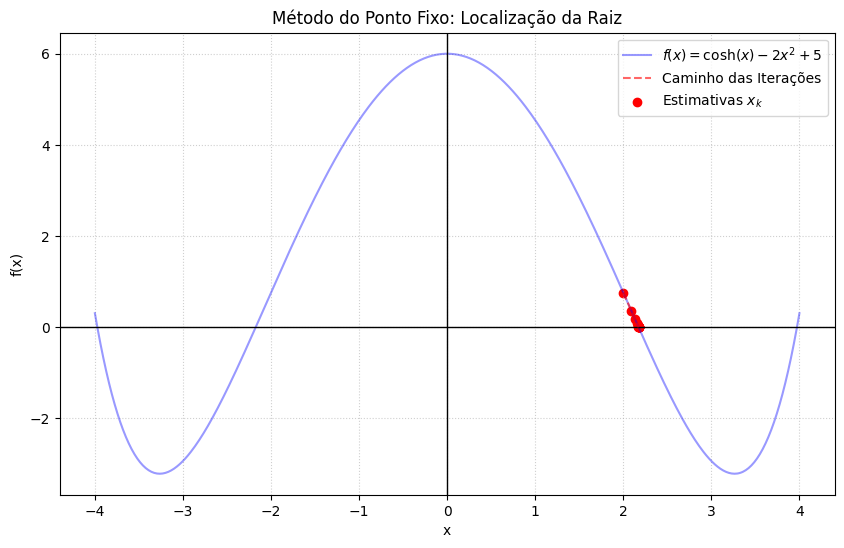

Iter  | x_k          | ea           | |f(x)|      
--------------------------------------------------
1     | 2.17429027   | 8.0160e-02   | 2.6188e-04  
2     | 2.17423015   | 2.7651e-05   | 8.2175e-10  
--------------------------------------------------
Convergência quadrática atingida em 2 iterações.


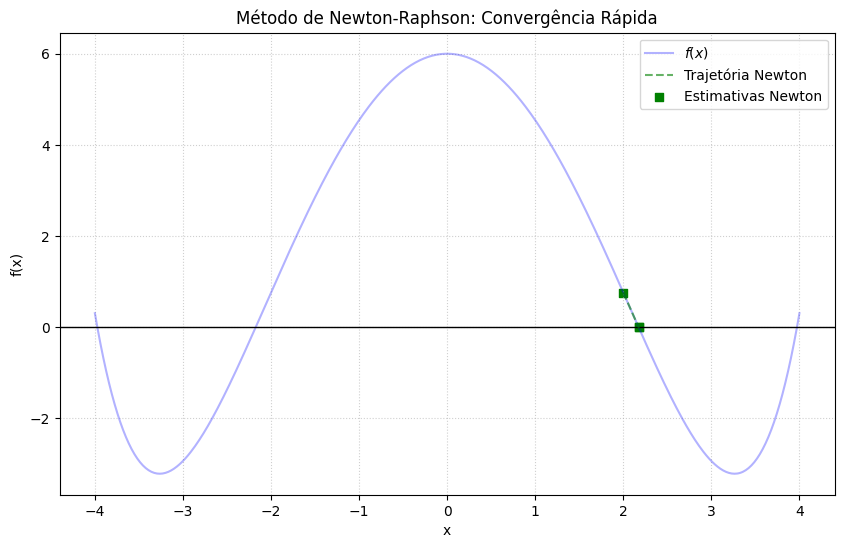

Iter  | x_k          | ea           | |f(x)|      
--------------------------------------------------
1     | 2.17406397   | 3.4067e-02   | 7.2392e-04  
2     | 2.17422966   | 7.6208e-05   | 2.1458e-06  
--------------------------------------------------
Convergência atingida em 2 iterações.


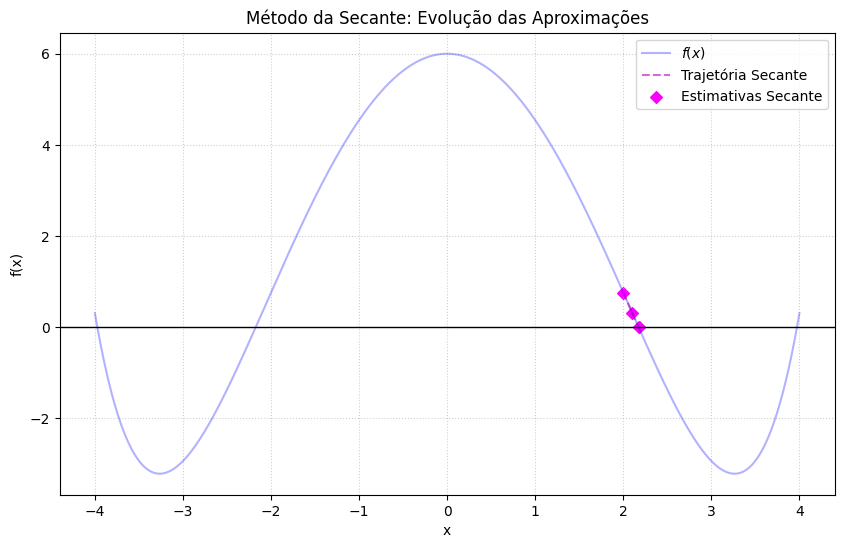

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#QUESTÃO 1 -----------------------------------------------------------------

def resolver_grafico():
    A, B, C = -4.0, 4.0, 0.1

    # Gerando o domínio x = {A, A+C, ..., B}
    x = np.arange(A, B + C, C)

    # f(x) = -sinh(x) - 2x^2 + 5 + exp(x)
    y = -np.sinh(x) - 2*(x**2) + 5 + np.exp(x)

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label=r'$f(x) = -\sinh(x) - 2x^2 + 5 + e^x$')
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.grid(True, linestyle='--')
    plt.title(r'Esboço Gráfico da Função f(x)')
    plt.xlabel(r'$x$')
    plt.ylabel(r'$f(x)$')
    plt.legend()
    plt.show()

resolver_grafico()

#-------------------------------------------------------------

#QUESTÃO 2 -----------------------------------------------------------------

def f(x):
    return np.cosh(x) - 2*(x**2) + 5

def phi(x):
    return np.sqrt((np.cosh(x) + 5) / 2)

x0 = 2.0
es = 1e-4
iter_max = 50

estimativas = [x0]
erros_a = []
valores_f = [f(x0)]

print(f"{'Iter':<5} | {'x_k':<12} | {'ea':<12} | {'|f(x)|':<12}")
print("-" * 50)

for k in range(iter_max):
    x_atual = estimativas[-1]
    x_proximo = phi(x_atual)

    ea = abs((x_proximo - x_atual) / x_proximo)
    fx_abs = abs(f(x_proximo))

    estimativas.append(x_proximo)
    erros_a.append(ea)
    valores_f.append(fx_abs)

    print(f"{k+1:<5} | {x_proximo:<12.8f} | {ea:<12.4e} | {fx_abs:<12.4e}")

    if ea < es and fx_abs < es:
        print("-" * 50)
        print(f"Convergência atingida em {k+1} iterações.")
        break

x_plot = np.linspace(-4, 4, 500)
y_plot = f(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, label=r'$f(x) = \cosh(x) - 2x^2 + 5$', color='blue', alpha=0.4)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)

x_iter = np.array(estimativas)
y_iter = f(x_iter)
plt.plot(x_iter, y_iter, 'r--', label='Caminho das Iterações', alpha=0.6)
plt.scatter(x_iter, y_iter, color='red', marker='o', label='Estimativas $x_k$')

plt.title('Método do Ponto Fixo: Localização da Raiz')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

#-------------------------------------------------------------

#QUESTÃO 4 -----------------------------------------------------------------

def df(x):
    return np.sinh(x) - 4*x

x0 = 2.0
es = 1e-4
iter_max = 50 # TESTE: Incluir um limite no numero de iteracoes

estimativas = [x0]
erros_a = []
valores_f = [f(x0)]

print(f"{'Iter':<5} | {'x_k':<12} | {'ea':<12} | {'|f(x)|':<12}")
print("-" * 50)

for k in range(iter_max):
    x_atual = estimativas[-1]
    fx_atual_abs = abs(f(x_atual))
    derivada = df(x_atual)

    # TESTE: Testar se f'(x) e igual ou muito proxima de zero
    if abs(derivada) < 1e-12:
        print("Erro: Derivada nula ou muito proxima de zero. O metodo falhou.")
        break

    x_proximo = x_atual - f(x_atual) / derivada

    ea = abs((x_proximo - x_atual) / x_proximo)
    fx_proximo_abs = abs(f(x_proximo))

    # TESTE: Testar se f(x) esta se aproximando de zero
    if k > 0 and fx_proximo_abs > fx_atual_abs:
        print(f"Aviso: |f(x)| aumentou na iteracao {k+1}. Possivel divergencia.")

    estimativas.append(x_proximo)
    erros_a.append(ea)

    print(f"{k+1:<5} | {x_proximo:<12.8f} | {ea:<12.4e} | {fx_proximo_abs:<12.4e}")

    if ea < es and fx_proximo_abs < es:
        print("-" * 50)
        print(f"Convergência quadrática atingida em {k+1} iterações.")
        break
else:
    # Caso o loop termine sem break, o limite de iteracoes foi atingido
    print("-" * 50)
    print("Aviso: Limite maximo de iteracoes atingido.")

x_plot = np.linspace(-4, 4, 500)
plt.figure(figsize=(10, 6))
plt.plot(x_plot, f(x_plot), label=r'$f(x)$', color='blue', alpha=0.3)
plt.axhline(0, color='black', lw=1)

x_iter = np.array(estimativas)
y_iter = f(x_iter)
plt.plot(x_iter, y_iter, 'g--', label='Trajetória Newton', alpha=0.6)
plt.scatter(x_iter, y_iter, color='green', marker='s', label='Estimativas Newton')

plt.title('Método de Newton-Raphson: Convergência Rápida')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

#-------------------------------------------------------------

#QUESTÃO 5 -----------------------------------------------------------------

x0 = 2.0
x1 = 2.1
es = 1e-4
iter_max = 50

estimativas = [x0, x1]
erros_a = []

print(f"{'Iter':<5} | {'x_k':<12} | {'ea':<12} | {'|f(x)|':<12}")
print("-" * 50)

for k in range(iter_max):
    x_ant = estimativas[-2]
    x_curr = estimativas[-1]

    f_ant = f(x_ant)
    f_curr = f(x_curr)

    x_next = x_curr - (f_curr * (x_curr - x_ant)) / (f_curr - f_ant)

    ea = abs((x_next - x_curr) / x_next)
    fx_abs = abs(f(x_next))

    estimativas.append(x_next)

    print(f"{k+1:<5} | {x_next:<12.8f} | {ea:<12.4e} | {fx_abs:<12.4e}")

    if ea < es and fx_abs < es:
        print("-" * 50)
        print(f"Convergência atingida em {k+1} iterações.")
        break

x_plot = np.linspace(-4, 4, 500)
plt.figure(figsize=(10, 6))
plt.plot(x_plot, f(x_plot), label=r'$f(x)$', color='blue', alpha=0.3)
plt.axhline(0, color='black', lw=1)

x_iter = np.array(estimativas)
y_iter = f(x_iter)
plt.plot(x_iter, y_iter, 'm--', label='Trajetória Secante', alpha=0.6)
plt.scatter(x_iter, y_iter, color='magenta', marker='D', label='Estimativas Secante')

plt.title('Método da Secante: Evolução das Aproximações')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()